<h1>ML Development</h1>

<h2>Importing Libraries</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

<h2>Loading Dataset</h2>

In [2]:
df = pd.read_csv("../data/processed/ml_dataset.csv")

df.head()

,customer_unique_id,Recency,Frequency,Monetary,Total_Orders,Total_Spent,Average_Order_Value,Average_Review_Score,Average_Delivery_Days,Churn,Customer_Segment,Predicted_CLV,Purchase_Propensity
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,1,141.90,141.90,5.0,6.0,0,Regular,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,1,27.19,27.19,4.0,3.0,0,Regular,27.19,0
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,86.22,86.22,3.0,25.0,1,Regular,86.22,0
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1,43.62,43.62,4.0,20.0,1,Regular,43.62,0
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1,196.89,196.89,5.0,13.0,1,Regular,196.89,0


<h2>Selecting Features</h2>

In [3]:
features = df[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

<h2>Scaling Features

In [4]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

<h2>Elbow Method

In [5]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

<h2>Plot

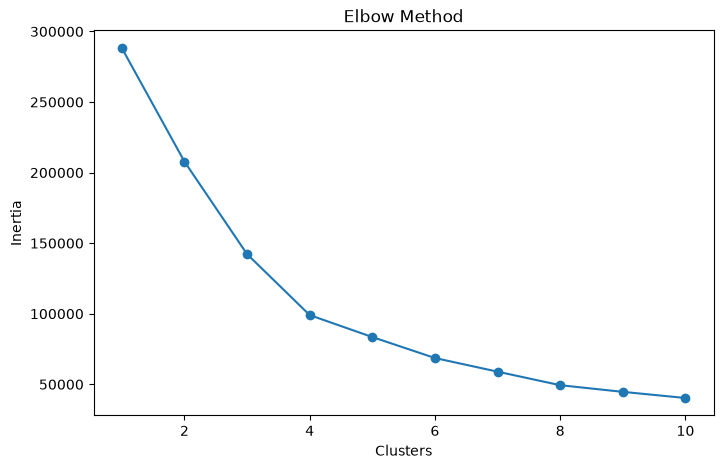

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

<h2>Training KMeans

In [7]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

<h2>Cluster Distribution

In [8]:
df["Cluster"].value_counts()

Cluster
0    52383
3    38925
2     2956
1     1832
Name: count, dtype: int64

<h2>Cluster Summary

In [9]:
cluster_summary = (
    df.groupby("Cluster")
    [
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ]
    .mean()
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,177.399309,1.000000,142.216021
1,287.549672,1.024017,1483.390868
2,267.847767,2.116712,315.877527
3,437.739037,1.000000,142.394950


<h2>Saving Dataset

In [10]:
df.to_csv(
    "../data/processed/ml_dataset_clustered.csv",
    index=False
)

print("Customer segmentation completed successfully.")

Customer segmentation completed successfully.


<h2>Cluster Naming

In [11]:
cluster_names = {
    0: "Active Customers",
    1: "High Value Customers",
    2: "Loyal Customers",
    3: "At-Risk Customers"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Cluster_Name"]].head()

,Cluster,Cluster_Name
0,0,Active Customers
1,0,Active Customers
2,3,At-Risk Customers
3,3,At-Risk Customers
4,3,At-Risk Customers
